# 01_Prepare_Dataset_FINAL

Fast cached-mask preparation with global RGB normalization and transparency-aware spatial splits.

## 1. Install dependencies

In [1]:
!pip -q install rasterio geopandas pyogrio rtree shapely scikit-image matplotlib pandas numpy tqdm

In [2]:
from pathlib import Path
import json, math, random, warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
from rasterio.enums import ColorInterp, Resampling
from shapely.geometry import box
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Mount Google Drive and define paths

In [3]:
from google.colab import drive
DRIVE_ROOT = Path("/content/drive")
MYDRIVE = DRIVE_ROOT / "MyDrive"
if not MYDRIVE.exists() or not any(MYDRIVE.iterdir()):
    drive.mount(str(DRIVE_ROOT))
else:
    print("Google Drive already mounted:", MYDRIVE)

PROJECT_ROOT = MYDRIVE / "Colab Notebooks" / "Musanga"
DATA_DIR = PROJECT_ROOT / "data"
WORK_DIR = PROJECT_ROOT / "work"
INDEX_DIR = WORK_DIR / "indices"
QC_DIR = WORK_DIR / "qc"
for path in [WORK_DIR, INDEX_DIR, QC_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RASTER_PATH = DATA_DIR / "Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif"
SHAPEFILE_PATH = DATA_DIR / "Sample_Musanga_others_2020_2024_complet.shp"
MUSANGA_MASK_PATH = WORK_DIR / "musanga_reference_mask.tif"
PATCH_INDEX_PATH = INDEX_DIR / "musanga_patch_index.csv"
CONFIG_PATH = WORK_DIR / "project_config.json"

assert RASTER_PATH.exists(), f"Missing raster: {RASTER_PATH}"
assert SHAPEFILE_PATH.exists(), f"Missing shapefile: {SHAPEFILE_PATH}"

Mounted at /content/drive


## 3. Configuration

In [4]:
PATCH_SIZE = 512
STRIDE = 256

# Smaller than before so positive crowns are distributed over enough spatial blocks.
SPLIT_BLOCK_PATCHES = 3

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

NEGATIVE_TO_POSITIVE_RATIO = 2.0
MIN_POSITIVE_PIXELS = 25

# Exclude windows that are mostly transparent.
MIN_VALID_FRACTION = 0.25

INCLUDE_PARTIAL_EDGE_WINDOWS = True

assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-8

FORCE_REBUILD_REFERENCE_MASK = False

## 4. Inspect raster metadata and estimate global RGB normalization

In [5]:
with rasterio.open(RASTER_PATH) as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("Dtypes:", src.dtypes)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)
    print("Color interpretation:", src.colorinterp)

Width: 44359
Height: 23217
Bands: 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
CRS: EPSG:32635
Bounds: BoundingBox(left=308618.12322, bottom=31867.767450000003, right=311735.23015, top=33499.22604)
Nodata: None
Color interpretation: (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>, <ColorInterp.alpha: 6>)


RGB bands: [1, 2, 3]
Global RGB low: [28.0, 50.0, 43.0]
Global RGB high: [159.0, 169.0, 124.0]


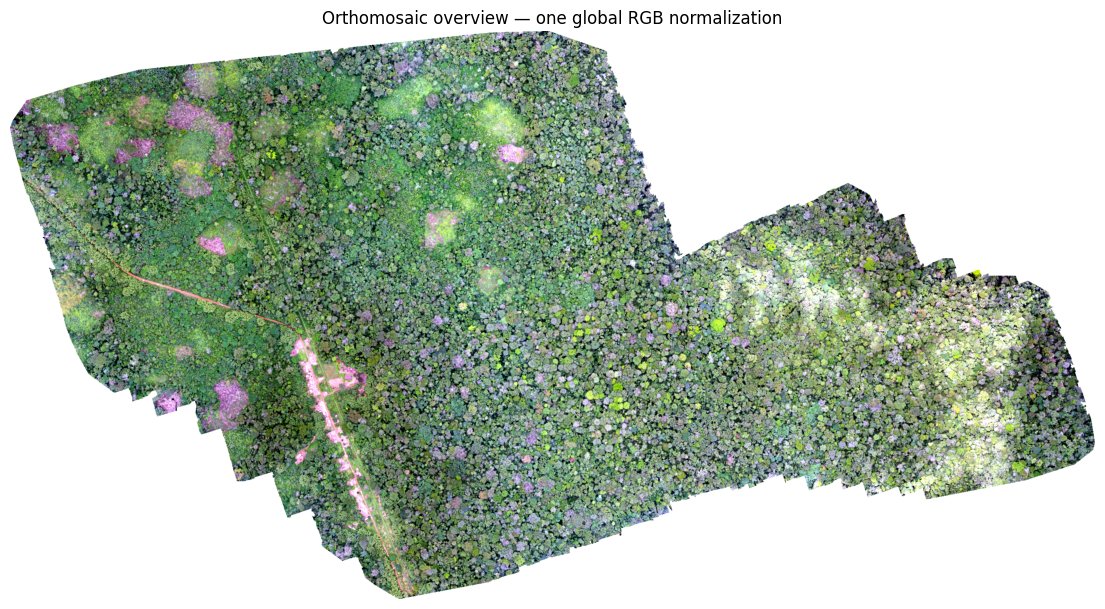

In [6]:
def select_rgb_bands(src):
    ci = list(src.colorinterp)
    try:
        return [ci.index(ColorInterp.red)+1, ci.index(ColorInterp.green)+1, ci.index(ColorInterp.blue)+1]
    except ValueError:
        if src.count < 3:
            raise ValueError("Raster has fewer than three bands.")
        return [1, 2, 3]

with rasterio.open(RASTER_PATH) as src:
    RGB_BANDS = select_rgb_bands(src)
    factor = max(1, int(max(src.width, src.height) / 2500))
    out_h = max(1, src.height // factor)
    out_w = max(1, src.width // factor)
    sample_rgb = src.read(RGB_BANDS, out_shape=(3, out_h, out_w), resampling=Resampling.bilinear).astype(np.float32)
    sample_valid = src.dataset_mask(out_shape=(out_h, out_w)) > 0

GLOBAL_RGB_LOW, GLOBAL_RGB_HIGH = [], []
for band_index in range(3):
    values = sample_rgb[band_index][sample_valid]
    if values.size == 0:
        raise ValueError("No visible raster pixels found.")
    low, high = np.percentile(values, [1, 99])
    if high <= low:
        high = low + 1.0
    GLOBAL_RGB_LOW.append(float(low))
    GLOBAL_RGB_HIGH.append(float(high))

print("RGB bands:", RGB_BANDS)
print("Global RGB low:", GLOBAL_RGB_LOW)
print("Global RGB high:", GLOBAL_RGB_HIGH)

def normalize_rgb_global(rgb_chw, valid_mask=None):
    rgb_chw = rgb_chw.astype(np.float32)
    out = np.zeros_like(rgb_chw, dtype=np.float32)
    for band_index in range(3):
        low = GLOBAL_RGB_LOW[band_index]
        high = GLOBAL_RGB_HIGH[band_index]
        out[band_index] = np.clip((rgb_chw[band_index] - low) / max(high-low, 1e-6), 0, 1)
    out = np.moveaxis(out, 0, -1)
    if valid_mask is not None:
        out[~valid_mask] = 1.0
    return out

overview = normalize_rgb_global(sample_rgb, sample_valid)
plt.figure(figsize=(14,10))
plt.imshow(overview)
plt.title("Orthomosaic overview — one global RGB normalization")
plt.axis("off")
plt.show()

## 5. Read and validate Musanga polygons

In [7]:
labels = gpd.read_file(SHAPEFILE_PATH)
print("Rows:", len(labels))
print("Columns:", list(labels.columns))
print("CRS:", labels.crs)

if "Clss_ID" not in labels.columns:
    raise KeyError("Expected field 'Clss_ID' was not found.")

labels = labels[labels.geometry.notna() & ~labels.geometry.is_empty].copy()
labels["Clss_ID_num"] = pd.to_numeric(labels["Clss_ID"], errors="coerce")

musanga = labels[np.isclose(labels["Clss_ID_num"], 1.0, equal_nan=False)].copy()

if musanga.empty:
    raise ValueError("No polygons with Clss_ID == 1 were found.")

with rasterio.open(RASTER_PATH) as src:
    if src.crs is None:
        raise ValueError("Raster CRS is undefined.")
    if musanga.crs is None:
        raise ValueError("Shapefile CRS is undefined.")
    if musanga.crs != src.crs:
        musanga = musanga.to_crs(src.crs)

    raster_geom = box(*src.bounds)
    musanga = musanga[musanga.intersects(raster_geom)].copy()
    musanga["geometry"] = musanga.geometry.intersection(raster_geom)
    musanga = musanga[~musanga.geometry.is_empty].copy()

print("Musanga polygons intersecting raster:", len(musanga))
MUSANGA_SINDEX = musanga.sindex

Rows: 7374
Columns: ['Clss_ID', 'Source', 'Clss_nm', 'Site_x', 'Plt_nm_x', 'Years_x', 'Site_y', 'Plt_nm_y', 'Years_y', 'geometry']
CRS: EPSG:32635
Musanga polygons intersecting raster: 1346


## 6. Create or reuse full-resolution cached Musanga mask

In [10]:
# ======================================================================================
# BLOCK 07 — CREATE OR REUSE CACHED FULL-RESOLUTION MUSANGA MASK
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 07 — CREATE OR REUSE CACHED FULL-RESOLUTION MUSANGA MASK")
print("=" * 100)

# Cached binary reference mask:
#   1 = Musanga
#   0 = non-Musanga / background
#
# Transparent orthomosaic pixels are handled separately through
# RASTER_PATH.dataset_mask() and are not encoded here.

MUSANGA_MASK_PATH = (
    WORK_DIR
    / "musanga_reference_mask.tif"
)

# Set this to True only when the shapefile labels have changed
# or when you explicitly want to rebuild the mask.
FORCE_REBUILD_REFERENCE_MASK = False


# Remove a previous mask only when rebuilding is requested.
if (
    FORCE_REBUILD_REFERENCE_MASK
    and MUSANGA_MASK_PATH.exists()
):
    MUSANGA_MASK_PATH.unlink()

    print(
        "Deleted existing cached mask:",
        MUSANGA_MASK_PATH,
    )


rebuild_mask = (
    FORCE_REBUILD_REFERENCE_MASK
    or not MUSANGA_MASK_PATH.exists()
)


if rebuild_mask:

    print(
        "Creating cached Musanga reference mask..."
    )

    with rasterio.open(
        RASTER_PATH
    ) as src:

        # Start from the source profile but remove inherited
        # TIFF block settings. Some source mosaics contain
        # block sizes that are invalid for tiled GeoTIFF output.
        mask_profile = src.profile.copy()

        mask_profile.pop(
            "blockxsize",
            None,
        )

        mask_profile.pop(
            "blockysize",
            None,
        )

        mask_profile.update(
            driver="GTiff",
            count=1,
            dtype="uint8",
            nodata=0,
            compress="deflate",
            predictor=2,
            tiled=True,
            blockxsize=512,
            blockysize=512,
            BIGTIFF="YES",
        )

        with rasterio.open(
            MUSANGA_MASK_PATH,
            "w",
            **mask_profile,
        ) as dst:

            # Iterate over the output mask blocks.
            # This avoids rasterizing the entire mosaic in RAM.
            output_blocks = list(
                dst.block_windows(1)
            )

            for _, window in tqdm(
                output_blocks,
                desc="Rasterizing Musanga blocks",
            ):

                window_bounds = (
                    rasterio.windows.bounds(
                        window,
                        src.transform,
                    )
                )

                footprint = box(
                    *window_bounds
                )

                candidate_ids = list(
                    MUSANGA_SINDEX.query(
                        footprint,
                        predicate="intersects",
                    )
                )

                if candidate_ids:

                    candidate_geometries = [
                        geometry
                        for geometry
                        in musanga.iloc[
                            candidate_ids
                        ].geometry
                        if (
                            geometry is not None
                            and not geometry.is_empty
                        )
                    ]

                    if candidate_geometries:

                        block_mask = rasterize(
                            [
                                (
                                    geometry,
                                    1,
                                )
                                for geometry
                                in candidate_geometries
                            ],
                            out_shape=(
                                int(
                                    window.height
                                ),
                                int(
                                    window.width
                                ),
                            ),
                            transform=(
                                src.window_transform(
                                    window
                                )
                            ),
                            fill=0,
                            all_touched=False,
                            dtype="uint8",
                        )

                    else:

                        block_mask = np.zeros(
                            (
                                int(
                                    window.height
                                ),
                                int(
                                    window.width
                                ),
                            ),
                            dtype=np.uint8,
                        )

                else:

                    block_mask = np.zeros(
                        (
                            int(
                                window.height
                            ),
                            int(
                                window.width
                            ),
                        ),
                        dtype=np.uint8,
                    )

                dst.write(
                    block_mask,
                    1,
                    window=window,
                )

    print(
        "Saved cached Musanga mask:",
        MUSANGA_MASK_PATH,
    )


else:

    print(
        "Reusing cached Musanga mask:",
        MUSANGA_MASK_PATH,
    )


# ======================================================================================
# VALIDATE CACHED MASK
# ======================================================================================

with rasterio.open(
    RASTER_PATH
) as image_src, rasterio.open(
    MUSANGA_MASK_PATH
) as mask_src:

    if (
        image_src.width
        != mask_src.width
    ):
        raise ValueError(
            "Cached mask width does not match orthomosaic."
        )

    if (
        image_src.height
        != mask_src.height
    ):
        raise ValueError(
            "Cached mask height does not match orthomosaic."
        )

    if (
        image_src.transform
        != mask_src.transform
    ):
        raise ValueError(
            "Cached mask transform does not match orthomosaic."
        )

    if (
        image_src.crs
        != mask_src.crs
    ):
        raise ValueError(
            "Cached mask CRS does not match orthomosaic."
        )

    print(
        "Mask width:",
        mask_src.width,
    )

    print(
        "Mask height:",
        mask_src.height,
    )

    print(
        "Mask CRS:",
        mask_src.crs,
    )

    print(
        "Mask block shapes:",
        mask_src.block_shapes,
    )


print(
    "Cached Musanga mask is valid."
)


BLOCK 07 — CREATE OR REUSE CACHED FULL-RESOLUTION MUSANGA MASK
Creating cached Musanga reference mask...


Rasterizing Musanga blocks:   0%|          | 0/4002 [00:00<?, ?it/s]

Saved cached Musanga mask: /content/drive/MyDrive/Colab Notebooks/Musanga/work/musanga_reference_mask.tif
Mask width: 44359
Mask height: 23217
Mask CRS: EPSG:32635
Mask block shapes: [(512, 512)]
Cached Musanga mask is valid.


## 7. Fast patch index creation from cached rasters

In [12]:

def window_starts(
    length,
    patch_size,
    stride,
    include_partial=True,
):
    starts = list(
        range(
            0,
            max(1, length - patch_size + 1),
            stride,
        )
    )

    if include_partial:
        last = max(
            0,
            length - patch_size,
        )

        if (
            not starts
            or starts[-1] != last
        ):
            starts.append(last)

    return sorted(
        set(starts)
    )
rows = []
with rasterio.open(RASTER_PATH) as src, rasterio.open(MUSANGA_MASK_PATH) as label_src:
    row_starts = window_starts(src.height, PATCH_SIZE, STRIDE, INCLUDE_PARTIAL_EDGE_WINDOWS)
    col_starts = window_starts(src.width, PATCH_SIZE, STRIDE, INCLUDE_PARTIAL_EDGE_WINDOWS)
    block_size_px = PATCH_SIZE * SPLIT_BLOCK_PATCHES
    progress = tqdm(total=len(row_starts)*len(col_starts), desc="Scanning patches")
    for row_off in row_starts:
        for col_off in col_starts:
            width = min(PATCH_SIZE, src.width-col_off)
            height = min(PATCH_SIZE, src.height-row_off)
            window = Window(col_off, row_off, width, height)
            musanga_mask = label_src.read(1, window=window) == 1
            valid_mask = src.dataset_mask(window=window) > 0
            positive_pixels = int(np.sum(musanga_mask & valid_mask))
            valid_pixels = int(valid_mask.sum())
            valid_fraction = valid_pixels / valid_mask.size if valid_mask.size else 0.0
            block_row = int(row_off // block_size_px)
            block_col = int(col_off // block_size_px)
            rows.append({
                "patch_id": f"r{int(row_off):07d}_c{int(col_off):07d}",
                "row_off": int(row_off), "col_off": int(col_off),
                "height": int(height), "width": int(width),
                "split_block_row": block_row, "split_block_col": block_col,
                "block_id": f"{block_row}_{block_col}",
                "positive_pixels": positive_pixels,
                "has_musanga": positive_pixels >= MIN_POSITIVE_PIXELS,
                "valid_pixels": valid_pixels, "valid_fraction": valid_fraction,
            })
            progress.update(1)
    progress.close()

patch_index = pd.DataFrame(rows)
before = len(patch_index)
patch_index = patch_index[patch_index["valid_fraction"] >= MIN_VALID_FRACTION].copy()
print("Candidate patches:", before)
print("After excluding mostly transparent patches:", len(patch_index))
print("Positive patches:", int(patch_index["has_musanga"].sum()))

Scanning patches:   0%|          | 0/15570 [00:00<?, ?it/s]

Candidate patches: 15570
After excluding mostly transparent patches: 9810
Positive patches: 3344


## 8. Assign positive spatial blocks to train, validation, and test

In [13]:
rng = np.random.default_rng(SEED)

block_summary = (
    patch_index
    .groupby("block_id", as_index=False)
    .agg(
        block_row=("split_block_row", "first"),
        block_col=("split_block_col", "first"),
        n_patches=("patch_id", "size"),
        n_positive_patches=("has_musanga", "sum"),
        positive_pixels=("positive_pixels", "sum"),
    )
)

positive_blocks = block_summary[
    block_summary["n_positive_patches"] > 0
].copy()

negative_blocks = block_summary[
    block_summary["n_positive_patches"] == 0
].copy()

print("Spatial blocks:", len(block_summary))
print("Positive spatial blocks:", len(positive_blocks))
print("Background-only spatial blocks:", len(negative_blocks))

if len(positive_blocks) < 3:
    raise ValueError(
        "Fewer than three positive spatial blocks were found. "
        "Reduce SPLIT_BLOCK_PATCHES, for example to 2, and rerun."
    )

positive_blocks["_tie"] = rng.random(len(positive_blocks))
positive_blocks = positive_blocks.sort_values(
    ["positive_pixels", "_tie"],
    ascending=[False, True],
).reset_index(drop=True)

split_order = ["train", "val", "test"]
target_fractions = {
    "train": TRAIN_FRACTION,
    "val": VAL_FRACTION,
    "test": TEST_FRACTION,
}

assignments = {}
positive_pixel_totals = {s: 0 for s in split_order}

# Guarantee at least one positive block per split.
for i, split in enumerate(split_order):
    rec = positive_blocks.iloc[i]
    assignments[rec.block_id] = split
    positive_pixel_totals[split] += int(rec.positive_pixels)

total_positive_pixels = int(positive_blocks["positive_pixels"].sum())
target_positive_pixels = {
    s: total_positive_pixels * target_fractions[s]
    for s in split_order
}

# Greedy assignment of the remaining positive blocks.
for _, rec in positive_blocks.iloc[3:].iterrows():
    normalized_deficit = {
        s: (
            target_positive_pixels[s] - positive_pixel_totals[s]
        ) / max(target_positive_pixels[s], 1.0)
        for s in split_order
    }
    chosen = max(normalized_deficit, key=normalized_deficit.get)
    assignments[rec.block_id] = chosen
    positive_pixel_totals[chosen] += int(rec.positive_pixels)

# Assign background-only blocks to approximate target block counts.
negative_blocks = negative_blocks.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

target_block_counts = {
    "train": int(round(len(block_summary) * TRAIN_FRACTION)),
    "val": int(round(len(block_summary) * VAL_FRACTION)),
}
target_block_counts["test"] = (
    len(block_summary)
    - target_block_counts["train"]
    - target_block_counts["val"]
)

def current_count(split):
    return sum(v == split for v in assignments.values())

for _, rec in negative_blocks.iterrows():
    deficits = {
        s: target_block_counts[s] - current_count(s)
        for s in split_order
    }
    chosen = max(deficits, key=deficits.get)
    assignments[rec.block_id] = chosen

patch_index["split"] = patch_index["block_id"].map(assignments)

if patch_index["split"].isna().any():
    raise RuntimeError("Some spatial blocks were not assigned.")

Spatial blocks: 305
Positive spatial blocks: 243
Background-only spatial blocks: 62


## 9. Balance visible background patches within each split

In [14]:
selected_parts = []

for split, group in patch_index.groupby("split"):
    positives = group[group["has_musanga"]].copy()
    negatives = group[~group["has_musanga"]].copy()

    if positives.empty:
        raise RuntimeError(f"Split {split!r} has no positive patches.")

    n_neg_keep = min(
        len(negatives),
        max(1, int(math.ceil(len(positives) * NEGATIVE_TO_POSITIVE_RATIO))),
    )

    if n_neg_keep < len(negatives):
        negatives = negatives.sample(n=n_neg_keep, random_state=SEED)

    selected_parts.extend([positives, negatives])

patch_index = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["split", "row_off", "col_off"])
    .reset_index(drop=True)
)

# Confirm spatial isolation.
block_split_counts = patch_index.groupby("block_id")["split"].nunique()
assert block_split_counts.max() == 1, "Spatial leakage detected."

patch_index.to_csv(PATCH_INDEX_PATH, index=False)

display(
    patch_index.groupby(["split", "has_musanga"])
    .size()
    .rename("n_patches")
    .reset_index()
)

display(
    patch_index[patch_index["has_musanga"]]
    .groupby("split")
    .agg(
        positive_patches=("patch_id", "size"),
        positive_pixels=("positive_pixels", "sum"),
        positive_blocks=("block_id", "nunique"),
    )
)

print("Saved:", PATCH_INDEX_PATH)

,split,has_musanga,n_patches
0,test,False,857
1,test,True,476
2,train,False,4653
3,train,True,2372
4,val,False,956
5,val,True,496


,positive_patches,positive_pixels,positive_blocks
split,,,
test,476,9251615,35
train,2372,43164988,173
val,496,9253182,35


Saved: /content/drive/MyDrive/Colab Notebooks/Musanga/work/indices/musanga_patch_index.csv


## 10. Save shared configuration

In [15]:
config = {
    "project_root": str(PROJECT_ROOT),
    "data_dir": str(DATA_DIR),
    "work_dir": str(WORK_DIR),
    "raster_path": str(RASTER_PATH),
    "shapefile_path": str(SHAPEFILE_PATH),
    "musanga_mask_path": str(MUSANGA_MASK_PATH),
    "patch_index_path": str(PATCH_INDEX_PATH),
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "split_block_patches": SPLIT_BLOCK_PATCHES,
    "seed": SEED,
    "label_field": "Clss_ID",
    "musanga_value": 1.0,
    "min_positive_pixels": MIN_POSITIVE_PIXELS,
    "min_valid_fraction": MIN_VALID_FRACTION,
    "rgb_bands": RGB_BANDS,
    "global_rgb_low": GLOBAL_RGB_LOW,
    "global_rgb_high": GLOBAL_RGB_HIGH,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2))
print("Saved:", CONFIG_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/Musanga/work/project_config.json


## 11. Visual quality control

In [16]:
sample_parts = []
for split in ["train", "val", "test"]:
    pos = patch_index[(patch_index.split == split) & patch_index.has_musanga]
    neg = patch_index[(patch_index.split == split) & ~patch_index.has_musanga]
    if len(pos): sample_parts.append(pos.sample(min(2, len(pos)), random_state=SEED))
    if len(neg): sample_parts.append(neg.sample(min(1, len(neg)), random_state=SEED))
samples = pd.concat(sample_parts, ignore_index=True)

with rasterio.open(RASTER_PATH) as src, rasterio.open(MUSANGA_MASK_PATH) as label_src:
    for _, rec in samples.iterrows():
        window = Window(int(rec.col_off), int(rec.row_off), int(rec.width), int(rec.height))
        image = src.read(RGB_BANDS, window=window, boundless=True, fill_value=0)
        valid = src.dataset_mask(window=window, boundless=True) > 0
        mask = label_src.read(1, window=window, boundless=True, fill_value=0) == 1
        padded_image = np.zeros((3, PATCH_SIZE, PATCH_SIZE), dtype=image.dtype)
        padded_valid = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=bool)
        padded_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=bool)
        h,w = image.shape[1:]
        padded_image[:,:h,:w] = image
        padded_valid[:h,:w] = valid
        padded_mask[:h,:w] = mask
        vis = normalize_rgb_global(padded_image, padded_valid)
        fig, ax = plt.subplots(figsize=(7,7))
        ax.imshow(vis)
        ax.imshow(np.ma.masked_where(~padded_mask, padded_mask), alpha=0.4, cmap="Reds")
        ax.set_title(f"{rec.patch_id} | {rec.split} | valid={rec.valid_fraction:.2f} | positive={rec.positive_pixels}")
        ax.axis("off")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

Proceed to **02_Train_UNet.ipynb** after checking alignment and split summaries.